Q3: does the answer generated from the docs(context) is fully based on docs ? or did llm added anything extra !???


    
is it fully , partially or not supported ?

In [30]:

from typing import List, TypedDict,Literal
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace    #for structure output !
from pydantic import BaseModel,Field

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
docs = (
    PyPDFLoader("../documents/Company_Policies.pdf").load() +
    PyPDFLoader("../documents/Company_Profile.pdf").load() +
    PyPDFLoader("../documents/Product_and_Pricing.pdf").load()
)
docs


[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '../documents/Company_Policies.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x7f\nSick Leave: 10 working days per year\n\x7f\nCasual Leave: 6 working days per year\n\x7f\nMaternity Leave:

In [3]:
len(docs)

8

In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=100).split_documents(docs)
chunks

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '../documents/Company_Policies.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x7f\nSick Leave: 10 working days per year\n\x7f'),
 Document(metadata={'producer': 'ReportLab PDF Library - ww

In [5]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = Chroma.from_documents(chunks,embeddings)
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2415.91it/s]


In [37]:
llm=ChatGroq(model="llama-3.1-8b-instant")
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")  #for structured output ...

In [38]:

# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs : list[Document]  


    #new ⭐
    context : str    
     # Post-generation verification
    issup: Literal["fully_supported", "partially_supported", "no_support"] 
    evidence : list[str]

    answer: str

In [39]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = model.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}



In [40]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }

In [41]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [42]:

class is_relevant_schema(BaseModel):
    is_relevant: bool = Field( ... , description="True if the document helps answer the question, else False.")

relevant_prompt = ChatPromptTemplate.from_messages([
    ("system",
    "You are judging document relevance.\n"
    "Return JSON that matches this schema:\n"
    "{{'is_relevant': boolean}}\n\n"
    "A document is relevant if it contains information useful for answering the question."),
    ("user",
    "Question:\n{question}\n\nDocument:\n{document}")
])

relevant_chain = relevant_prompt | model.with_structured_output(is_relevant_schema)

def is_relevant(state:State) -> State:
    
    relevant_docs:list[Document] = []

    for doc in state['docs']:
        decision : bool = relevant_chain.invoke({
            'question': state['question'],
            'document' : doc.page_content
        })

        if decision.is_relevant:
            relevant_docs.append(doc)
    
    return {'relevant_docs': relevant_docs}






In [43]:
# new ⭐
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)


def generate_from_context(state:State)->State:
    context = "\n\n----\n\n".join(doc.page_content for doc in state['relevant_docs']).strip()

    if not context:
        return {"answer": "No relevant document found.", "context": ""}
    
    answer = llm.invoke(
        rag_generation_prompt.format_messages(
            question = state['question'],
            context = context
        )
    )

    return {'answer':answer.content, 'context':context}

In [44]:
# new ⭐
def no_relevant_docs(state:State) -> State:
    # we can search the relevant docs from web search if necessary !!
    return {"answer": "No relevant document found.", "context": ""}

In [45]:
#new ⭐
# does the generated answer form the context  support the retrirved docs ?? or is thrier anything extra??

class is_sup_schema(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

is_sup_prompt = ChatPromptTemplate.from_messages([
    ("system", """
Check whether ANSWER is supported by CONTEXT.

Return:
- issup: fully_supported, partially_supported, or no_support
- evidence: up to 3 short quotes from CONTEXT

Rules:
- fully_supported: every claim is explicitly supported by CONTEXT.
- partially_supported: core facts are supported but ANSWER adds unsupported interpretation, inference, or qualitative wording.
- no_support: key claims are unsupported or unrelated.

Be strict. Use only CONTEXT.
"""),
        ("human",
         "Question:\n{question}\n\n"
        "Answer:\n{answer}\n\n"
        "Context:\n{context}\n")
])


is_sup_chain = is_sup_prompt | llm.with_structured_output(is_sup_schema)

def is_sup(state:State) -> State:
    decision : is_sup_schema = is_sup_chain.invoke({
        "question":state['question'],
        "answer":state['answer'],
        "context":state['context']
    })

    return {"issup": decision.issup,"evidence":decision.evidence}

In [46]:
# is retrival needed route
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

# #new ⭐
# after retrieved docs , if 0 relavant docs say no_relevant_docs , if more then 0 relevant docs generate answer from it 
def route_after_relevance(state:State)-> Literal["generate_from_context","no_relevant_docs"]:
    if state['relevant_docs'] and len(state['relevant_docs']) > 0 :
        return "generate_from_context"
    return "no_relevant_docs"

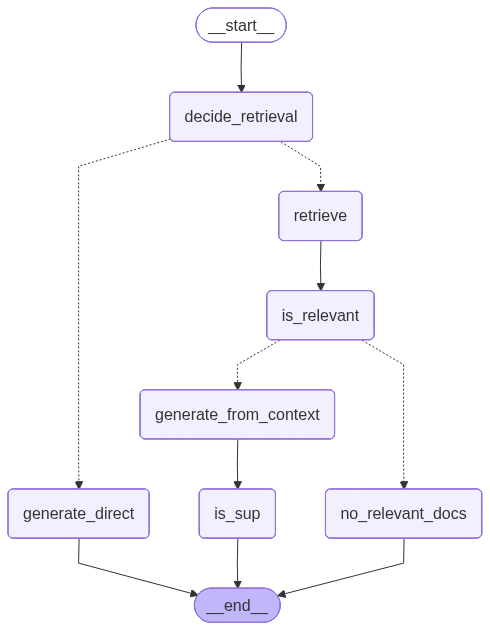

In [47]:

g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node('is_relevant',is_relevant)
g.add_node('generate_from_context',generate_from_context)
g.add_node('no_relevant_docs',no_relevant_docs)

g.add_node('is_sup',is_sup)
# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)
g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges("is_relevant",route_after_relevance,{"generate_from_context":"generate_from_context",
                                                            "no_relevant_docs":"no_relevant_docs"})

g.add_edge("generate_from_context","is_sup")
g.add_edge("is_sup",END)
g.add_edge("no_relevant_docs",END)

app = g.compile()
app

In [48]:
result = app.invoke(
    {
        "question": "How many employees does NexaAI have?",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
        "relevant_docs" : []
    }
)

print(f"answer : {result['answer']}\n\n\n") 
print(f"is_sup: {result['issup']}\n\n\n")
print(f"evidence: {result['evidence']}\n\n\n")
print(f"context : {result['context']}\n\n\n") 
print(f"no of relevant docs : {len(result['relevant_docs'])}")
print(f"relevant docs : {result['relevant_docs']}\n\n\n") 
print(f"no of docs : {len(result['docs'])}\n\n\n") 

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 7.031068598s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi

In [23]:
print(result['relevant_docs'])

[]


BadRequestError: (Request ID: Root=1-6a23ef69-49c81ff24c9a20bc63adfac0;e5e8e524-e1d7-4d6f-80a0-96f316a00c01)

Bad request:
{'message': "The requested model 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' is not supported by any provider you have enabled.", 'type': 'invalid_request_error', 'param': 'model', 'code': 'model_not_supported'}

{'type': 'user', 'id': '6872111443aa73db923a0799', 'name': 'haroon5', 'fullname': 'Mir Haroon Ali', 'email': 'mirharoonali143@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1782864000, 'isPro': False, 'avatarUrl': '/avatars/945303c4dcc421a530b4328e6508f2a0.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'langchain_token', 'role': 'read', 'createdAt': '2026-02-21T03:26:26.704Z'}}}
